In [98]:
import torch
import pde_model_sde
import viz

In [85]:
d = 2
seed = 42
dtype = torch.float32
device = None
score_sde_model = pde_model_sde.Isotropic_OU(d=d, seed=seed, dtype=dtype, device=device)

tensor([[ 1.5208, -0.0818],
        [-0.0818,  1.3549]])
tensor([1.3213, 1.5544])


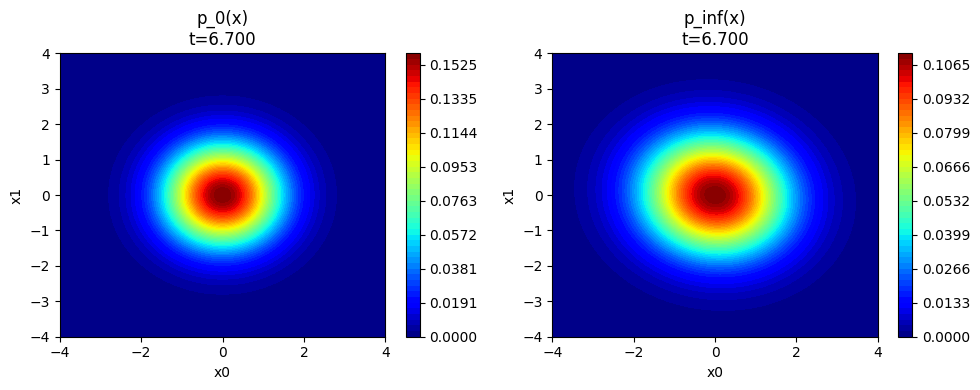

In [86]:
score_sde_model.d = d
score_sde_model.dtype = dtype
score_sde_model.device = device

score_sde_model.gaussian_obj = pde_model_sde.GeneralGaussian(d, gamma_strategy="min_max", seed=seed, dtype=dtype, device=device)
gamma_strategy = "min_max"
if gamma_strategy == "min_max":
    gamma_min = 1.3
    gamma_max = 2.2
    gamma = gamma_min + (gamma_max - gamma_min) * torch.rand(
        d, device=device, dtype=dtype
    )
elif gamma_strategy == "constant":
    gamma = 10*torch.ones(d)
elif gamma_strategy == "paper":
    # Eigenvalues: pairs lambda_{2i} ~ U([1, 1.1]), lambda_{2i+1} = 1/lambda_{2i}.
    gamma = torch.empty(d, dtype=dtype, device=device)
    n_pairs = d // 2
    if n_pairs > 0:
        pair_vals = 1.0 + 1.0 * torch.rand(n_pairs, dtype=dtype, device=device)
        gamma[0:2*n_pairs:2] = pair_vals
        gamma[1:2*n_pairs:2] = 1.0 / pair_vals
    if d % 2 == 1:
        gamma[-1] = 1.0 + 1.0 * torch.rand((), dtype=dtype, device=device)
score_sde_model.gaussian_obj.gamma = gamma

Q = score_sde_model.gaussian_obj.Q
score_sde_model.gaussian_obj.Sigma = Q.transpose(0, 1) @ (gamma.unsqueeze(1) * Q)
score_sde_model.gaussian_obj.Sigma_sqrt = Q.transpose(0, 1) @ (torch.sqrt(gamma).unsqueeze(1) * Q)


score_sde_model.Sigma = score_sde_model.gaussian_obj.Sigma
score_sde_model.dist_initial = torch.distributions.MultivariateNormal(
    loc=torch.zeros(d, dtype=dtype, device=device),
    covariance_matrix=torch.eye(d, dtype=dtype, device=device),
)
score_sde_model.dist_inf = torch.distributions.MultivariateNormal(
    loc=torch.zeros(d, dtype=dtype, device=device),
    covariance_matrix=score_sde_model.Sigma,
)
print(score_sde_model.gaussian_obj.Sigma)
print(score_sde_model.gaussian_obj.gamma)



p_ic = lambda X: score_sde_model.p0(X[:,:-1])
p_inf = lambda X: score_sde_model.p_inf(X[:,:-1])
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.5*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('ic', title="p_0(x)").heatmap(p_ic)
plotter.add_panel('final', title="p_inf(x)").heatmap(p_inf)
plotter.show_plot(t_val=6.7)